In [6]:
#!/usr/bin/env python
import os,sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import re
import math
#######################################
#### data export from files
# list_of_folders=['./scaling/7773X','./scaling/7763',
# './scaling/Flamingo',
# './scaling/Kanary','./scaling/Shaheen']
####### check logs from Shaheen3
list_of_folders=['./grid_perf/Shaheen3']
# list_of_folders=['./grid_perf/Shaheen3_2nd']
list_of_folders=['./grid_perf/Shaheen3_combined']
list_of_folders=['./grid_perf/Sh3']
list_of_folders=['./grid_perf/Sh3_']
list_of_folders=['/home/plotnips/Dropbox/PhD_proposal/work_with_david/Shaheen3_genoa_results/Sh3/Sh3']
# SH3 folder
list_of_folders=['/home/plotnips/Dropbox/PhD_proposal/work_with_david/Shaheen3_genoa_results/Sh3/Sh3']
list_of_folders=['/Users/pavelplotnitskii/Library/CloudStorage/Dropbox/PhD_proposal/work_with_david/Shaheen3_genoa_results/Sh3/Sh3']
list_of_folders=['/home/plotnips/Dropbox/PhD_proposal/work_with_david/Shaheen3_genoa_results/Sh3/Sh3']

# # emerald rapids folder
# list_of_folders=['./grid_perf/emerald_rapids']
sim_info=[]
times=[]
giga_points=[]
giga_flops = []
point_updates = []
flops=[]
method=[]
grids=[]
filenames=[]
cores=[]
import glob
####################### Parse files and aggregate them into the dataframe #######################
for data_folder in list_of_folders:
    print(os.getcwd())
    # filenames_list=os.listdir(data_folder)
    filenames_list=glob.glob(os.path.join(data_folder,'*--*') )
    #### filter filenames list
    for index,filename in enumerate(filenames_list):
        print(index,filename)
        with open(os.path.join(data_folder,filename),'r') as file:
            previous_line=''
            if '2023-12-17-13-41-42--0--388022' in filename:
                ss=1
            if '2023-12-01-20-34-09--4--723' in filename:
                ss=1
            for line in file:
                if '.out' in line:
                    info_line=line
                    lines=info_line.split(';')
                    for tmp_line in lines:
                        if '.out' in tmp_line:
                            launch_line=tmp_line
                    parsed_commands=launch_line.split(' ')
                    for parsed_command in parsed_commands:
                        if '.out' in parsed_command:
                            command_launch_binary=parsed_command
                            code_type=command_launch_binary.split('/')[-2]
                            # print(code_type)
                            if code_type=='SB': tmp_method='sb'
                            if code_type=='SB_abc': tmp_method='sb_abc'
                            if code_type=='TB': tmp_method='tb'
                            if code_type=='TB_abc': tmp_method='tb_abc'
                            if code_type=='SB_order2': tmp_method='sb_order2'
                            if code_type=='SB_order2_abc': tmp_method='sb_order2_abc'
                            if code_type=='TB_order2': tmp_method='tb_order2'
                            if code_type=='TB_order2_abc': tmp_method='tb_order2_abc'
                if '********** START SB KERNEL ***********' in line:
                    start_new_simulation_read=1                    
                    tmp_time=math.nan
                    tmp_giga_points=math.nan
                    tmp_giga_flops=math.nan
                    tmp_point_updates=math.nan
                    tmp_flops=math.nan
                    tmp_grid=math.nan
                elif '**** START TB KERNEL FIRST ORDER *****' in line:
                    start_new_simulation_read=1
                    tmp_time=math.nan
                    tmp_giga_points=math.nan
                    tmp_giga_flops=math.nan
                    tmp_point_updates=math.nan
                    tmp_flops=math.nan
                    tmp_grid=math.nan
                elif 'GRID' in line and issubclass(type(tmp_grid), str)==False:
                    if np.isnan(tmp_grid):
                        tmp_grid=(line.split('GRID')[-1])
                        tmp_grid=(tmp_grid.split('\n')[0])
                        tmp_grid=tmp_grid.strip()
                elif 'ELAPSED TIME (s)' in line and np.isnan(tmp_time):
                    tmp_time=(float(line.split()[-1]))
                elif 'GIGA POINT / s' in line and np.isnan(tmp_giga_points):
                    tmp_giga_points=(float(line.split()[-1]))
                elif 'GIGA FLOP / s' in line and np.isnan(tmp_giga_flops):
                    tmp_giga_flops=(float(line.split()[-1]))
                elif '# POINT UPDATES' in line and np.isnan(tmp_point_updates):
                    tmp_point_updates=(float(line.split()[-1]))
                elif 'FLOP' in line and np.isnan(tmp_flops):
                    tmp_flops=(float(line.split()[-1]))   
                elif 'R-' in line and 'R-TB1noABC' in line:
                    tmp_method='tb'
                elif 'R-' in line and 'R-TB1withABC' in line:
                    tmp_method='tb_abc'
                elif '# THREADS' in line:
                    tmp_ncores=(float(line.split()[-1]))
                elif ('********** END SB KERNEL *************' in line) or ('********** END TB KERNEL *************' in line):
                    cores.append(tmp_ncores)
                    filenames.append(filename)
                    sim_info.append(info_line)
                    times.append(tmp_time)
                    giga_points.append(tmp_giga_points)
                    giga_flops.append(tmp_giga_flops)
                    point_updates.append(tmp_point_updates)
                    flops.append(tmp_flops)
                    method.append( tmp_method)
                    grids.append(tmp_grid)
                    # code_type.append(tmp.split('_')[1])
                    # num_th.append( float (tmp.split('_')[2]) )
                    sss=1
                previous_line=line
        # print(filename)

# Créer un DataFrame à partir des listes
data = pd.DataFrame({
    'filenames':filenames,
    'method':method,
    'grids':grids,
    'giga_point_s':giga_points,
    'cores':cores,
    'sim_info':sim_info,
    'times':times,
    'giga_flop_s': giga_flops,
    'point_updates': point_updates,
    'Flops': flops,
    })
print(data.columns)
######################  find available grids
print(data['grids'].unique())
print(data['method'].unique())
# grids_=['512 x 512 x 512','1024 x 1024 x 512','2048 x 2048 x 512','2048 x 2048 x 1024','2048 x 2048 x 2048']
grids_=['512 x 512 x 512','1024 x 1024 x 512','2048 x 2048 x 512']
print('results will be plotted for grids=',grids_)
data_list_1st_grid=[]
data_list_2nd_grid=[]
metric='giga_point_s'
print(data['cores'].unique())
print(data['method'].unique())
print(data.columns)

####################### Create summary for dataframe  #######################
data_summary=data.copy()
data_summary=data_summary.drop(columns=['giga_flop_s','point_updates','Flops','sim_info','times'])
data_summary.to_excel(os.path.join("data_summary_whole_data.xlsx"))
####################### Parse dataframe and create list with values to plot #######################
ee=data[data['method']=='sb_abc']
# data_grid_sb=data_summary.iloc[0,:]
data_tmp = pd.DataFrame({
    'filenames':[],
    'method':[],
    'grids':[],
    'giga_point_s':[],
    'cores':[]})
thread_list=[96,192]

for grid_ in grids_:
    data_grid=data_summary[data_summary['grids']==grid_]
    data_grid=data_grid[data_grid['cores']==192]
    # data_grid=data_grid[data_grid['cores']==128]

    # choose code type
    data_grid_sb=data_grid[data_grid['method']=='sb']
    data_grid_sb_abc=data_grid[data_grid['method']=='sb_abc']
    data_grid_tb=data_grid[data_grid['method']=='tb']
    data_grid_tb_abc=data_grid[data_grid['method']=='tb_abc']

    data_grid_sb_order2=data_grid[data_grid['method']=='sb_order2']
    data_grid_sb_order2_abc=data_grid[data_grid['method']=='sb_order2_abc']
    data_grid_tb_order2=data_grid[data_grid['method']=='tb_order2']
    data_grid_tb_order2_abc=data_grid[data_grid['method']=='tb_order2_abc']

    # sort results by performance
    data_grid_sb=data_grid_sb.sort_values(by=['giga_point_s'],ascending=False)
    data_grid_sb_abc=data_grid_sb_abc.sort_values(by=['giga_point_s'],ascending=False)
    data_grid_tb=data_grid_tb.sort_values(by=['giga_point_s'],ascending=False)
    data_grid_tb_abc=data_grid_tb_abc.sort_values(by=['giga_point_s'],ascending=False)

    data_grid_sb_order2=data_grid_sb_order2.sort_values(by=['giga_point_s'],ascending=False)
    data_grid_sb_order2_abc=data_grid_sb_order2_abc.sort_values(by=['giga_point_s'],ascending=False)
    data_grid_tb_order2=data_grid_tb_order2.sort_values(by=['giga_point_s'],ascending=False)
    data_grid_tb_order2_abc=data_grid_tb_order2_abc.sort_values(by=['giga_point_s'],ascending=False)
    ######################### copy to excel
    # data_grid_sb_=data_grid_sb.iloc[0,:]
    # data_grid_sb_abc_=data_grid_sb_abc.iloc[0,:]
    # data_grid_tb_=data_grid_tb.iloc[0,:]
    # data_grid_tb_abc_=data_grid_tb_abc.iloc[0,:]
    # data_tmp = data_tmp.append(data_grid_sb_)
    # data_tmp = data_tmp.append(data_grid_sb_abc_)
    # data_tmp = data_tmp.append(data_grid_tb_)
    # data_tmp = data_tmp.append(data_grid_tb_abc_)
    
    # data_grid_sb_order2_=data_grid_sb_order2.iloc[0,:]
    # data_grid_sb_order2_abc_=data_grid_sb_order2_abc.iloc[0,:]
    # data_grid_tb_order2_=data_grid_tb_order2.iloc[0,:]
    # data_grid_tb_order2_abc_=data_grid_tb_order2_abc.iloc[0,:]
    # data_tmp = data_tmp.append(data_grid_sb_order2_)
    # data_tmp = data_tmp.append(data_grid_sb_order2_abc_)
    # data_tmp = data_tmp.append(data_grid_tb_order2_)
    # data_tmp = data_tmp.append(data_grid_tb_order2_abc_)
    #########################
    ##### record 1st order results
    if len(data_grid_sb[metric].values)!=0:
        sb_val=data_grid_sb[metric].values[0]
    else:
        sb_val=math.nan

    if len(data_grid_sb_abc[metric].values)!=0:
        sb_abc_val=data_grid_sb_abc[metric].values[0]
    else:
        sb_abc_val=math.nan

    if len(data_grid_tb[metric].values)!=0:
        tb_val=data_grid_tb[metric].values[0]
    else:
        tb_val=math.nan

    if len(data_grid_tb_abc[metric].values)!=0:
        tb_abc_val=data_grid_tb_abc[metric].values[0]
    else:
        tb_abc_val=math.nan
    print([grid_,sb_val,tb_val,sb_abc_val,tb_abc_val])
    data_list_1st_grid.append([grid_,sb_val,tb_val,sb_abc_val,tb_abc_val])
    ##### record 2nd order results
    if len(data_grid_sb_order2[metric].values)!=0:
        sb_val=data_grid_sb_order2[metric].values[0]
    else:
        sb_val=math.nan

    if len(data_grid_sb_order2_abc[metric].values)!=0:
        sb_abc_val=data_grid_sb_order2_abc[metric].values[0]
    else:
        sb_abc_val=math.nan

    if len(data_grid_tb_order2[metric].values)!=0:
        tb_val=data_grid_tb_order2[metric].values[0]
    else:
        tb_val=math.nan

    if len(data_grid_tb_order2_abc[metric].values)!=0:
        tb_abc_val=data_grid_tb_order2_abc[metric].values[0]
    else:
        tb_abc_val=math.nan
    data_list_2nd_grid.append([grid_,sb_val,tb_val,sb_abc_val,tb_abc_val])
    #########################
data_tmp.to_excel(os.path.join("data_summary2.xlsx"))
ss=1


/home/plotnips/Dropbox/Apps/Overleaf/2024_pasc_seismic/figures/pavel
0 /home/plotnips/Dropbox/PhD_proposal/work_with_david/Shaheen3_genoa_results/Sh3/Sh3/2024-01-09-09-06-47--762--589091
1 /home/plotnips/Dropbox/PhD_proposal/work_with_david/Shaheen3_genoa_results/Sh3/Sh3/2024-01-04-10-57-15--2207--556802
2 /home/plotnips/Dropbox/PhD_proposal/work_with_david/Shaheen3_genoa_results/Sh3/Sh3/2024-01-04-10-57-15--1019--555476
3 /home/plotnips/Dropbox/PhD_proposal/work_with_david/Shaheen3_genoa_results/Sh3/Sh3/2024-01-04-10-57-15--973--555429
4 /home/plotnips/Dropbox/PhD_proposal/work_with_david/Shaheen3_genoa_results/Sh3/Sh3/2023-12-17-13-41-42--1440--390283
5 /home/plotnips/Dropbox/PhD_proposal/work_with_david/Shaheen3_genoa_results/Sh3/Sh3/2024-01-07-08-42-11--832--579044
6 /home/plotnips/Dropbox/PhD_proposal/work_with_david/Shaheen3_genoa_results/Sh3/Sh3/2024-01-09-09-06-47--3973--592412
7 /home/plotnips/Dropbox/PhD_proposal/work_with_david/Shaheen3_genoa_results/Sh3/Sh3/2024-01-04-10-57

metric= gstencils
[0 1]
[0.25, 1.25]


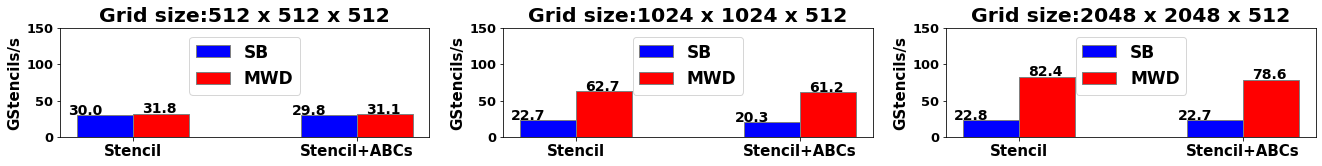

metric= gstencils
[0 1]
[0.25, 1.25]


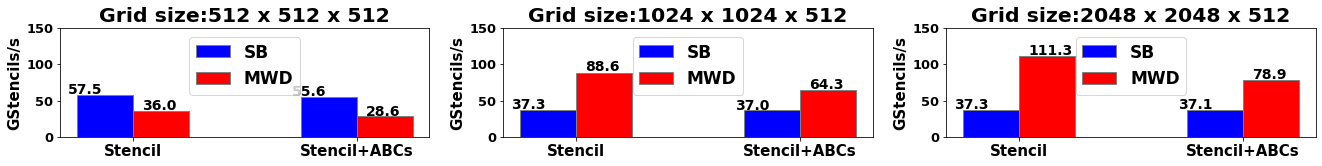

[ 96.  48.   1. 192.]
Index(['filenames', 'method', 'grids', 'giga_point_s', 'cores', 'sim_info',
       'times', 'giga_flop_s', 'point_updates', 'Flops'],
      dtype='object')


In [7]:

####################### Plot bar charts #######################
def plot_perf(data_list,save_paths,title='',metric='gstencils',gflops_limit=3300,gstencils_limit=100):
    print('metric=',metric)
    barWidth = 0.25
    # fig, ax = plt.subplots(1,len(data_list),figsize=(7.5*len(data_list),5))
    font = {'size': 17};    
    plt.rc('font', **font)
    plt.rcParams["font.weight"]="bold"
    # fig, ax = plt.subplots(1,len(data_list),figsize=(22*len(data_list),2.0))  # first variant
    fig, ax = plt.subplots(1,len(data_list),figsize=(7.5*len(data_list),2.0))  # second variant
    # plt.subplots_adjust(left=0.1, right=0.97,wspace=0.39, hspace=0.4)
    # plt.subplots_adjust(left=0.1, right=0.97,wspace=0.2, hspace=0.5)
    # Set position of bar on X axis 
    br1 = np.arange(2)
    br2 = [x + barWidth for x in br1]
    print(br1)
    print(br2)
    for (counter,data) in enumerate(data_list):
        grid_name=data[0];
        SB=[data[1],data[3]]; 
        TB=[data[2],data[4]];
        # Make the plot
        if len(data_list)==1:
            AX=ax
        else:
            AX=ax[counter]
        
        bars=AX.bar(br1, SB, color ='b', width = barWidth,edgecolor ='grey', label ='SB')
        for bar in bars:
            yval = bar.get_height()
            if metric=='gflops':
                plot_val=int(yval)
            else:
                plot_val=round(yval,1)
            AX.text(bar.get_x()-0.04,yval+yval*0.02,plot_val,fontsize=14,fontweight='bold')   # bold, normal
        
        bars=AX.bar(br2, TB, color ='r', width = barWidth,edgecolor ='grey', label ='MWD')
        for bar in bars:
            yval = bar.get_height()
            if metric=='gflops':
                plot_val=int(yval)
            else:
                plot_val=round(yval,1)
            AX.text(bar.get_x()+0.04,yval+yval*0.02,plot_val,fontsize=14,fontweight='bold')

        # AX.set_xticks([r + barWidth for r in range(len(SB))],['Stencil', 'Stencil+ABCs'])
        AX.set_xticks([0.125,1.125],['Stencil','Stencil+ABCs'], fontweight ='bold', fontsize = 15)
        # AX.set_yticks(fontsize=15)
        # plt.yticks(fontsize=13)
        AX.tick_params(axis='y', labelsize=13)

        if metric=='gflops':
            AX.set_ylabel('GFlop/s', fontweight ='bold', fontsize = 15)
            AX.set_ylim(bottom=0,top=gflops_limit)
        else:
            # AX.set_ylabel('GStencils/s', fontweight ='bold', fontsize = 18)
            AX.set_ylabel('GStencils/s', fontweight ='bold', fontsize = 15)
            AX.set_ylim(bottom=0,top=gstencils_limit)
        # AX.legend(loc='upper right')
        # AX.legend(loc='upper left')
        AX.legend(loc='upper center')
        # AX.set_title('Grid size:\n'+grid_name,fontweight='bold',fontsize=14)
        AX.set_title('Grid size:'+grid_name,fontweight='bold')

    # my_suptitle=fig.suptitle(title, fontsize=18,y=0,weight='bold')
    my_suptitle=fig.suptitle('',fontsize=18,y=0,weight='bold')
    plt.show()
    fig.savefig(save_paths[0],bbox_inches='tight',bbox_extra_artists=[my_suptitle])
    fig.savefig(save_paths[1],bbox_inches='tight',bbox_extra_artists=[my_suptitle])
    # fig.savefig(save_paths[0],bbox_extra_artists=[my_suptitle])
    # fig.savefig(save_paths[1],bbox_extra_artists=[my_suptitle])
    return None

save_paths=['../performances/sh3_1st_grids_gstencils.pdf',
            '../performances/sh3_1st_grids_gstencils.png']
plot_perf(data_list_1st_grid,save_paths,title='',metric='gstencils',gstencils_limit=150)

save_paths=['../performances/sh3_2nd_grids_gstencils.pdf',
            '../performances/sh3_2nd_grids_gstencils.png']
plot_perf(data_list_2nd_grid,save_paths,title='',metric='gstencils',gstencils_limit=150)
################ plot scalability plot ################################
print(data['cores'].unique())
print(data.columns)

[ 96.  48.   1. 192.]
['512 x 512 x 512', 1, 1.15859, 1.05452, 1.07941, 1.04698, 1.13999, 0.95512, 0.974397, 0.937691]
['512 x 512 x 512', 48, 6.00452, 27.6174, 5.99795, 27.5294, 9.86149, 38.3783, 9.87443, 32.8015]
['512 x 512 x 512', 96, 12.6503, 36.3454, 12.6331, 35.8683, 22.1246, 49.1649, 22.151, 41.2049]
['512 x 512 x 512', 192, 29.9592, 31.85, 29.821, 31.0635, 57.4558, 35.9784, 55.5878, 28.5993]
['1024 x 1024 x 512', 1, 1.10665, 1.14415, 1.01062, 1.01167, 1.05401, 1.05421, 0.860674, 0.826104]
['1024 x 1024 x 512', 48, 5.99032, 27.946, 5.98196, 27.2078, 9.7424, 37.6282, 9.73575, 29.154]
['1024 x 1024 x 512', 96, 11.5267, 44.8409, 11.4542, 43.9542, 18.7735, 55.9444, 19.0372, 42.2969]
['1024 x 1024 x 512', 192, 22.7049, 62.6628, 20.2959, 61.1967, 37.2563, 88.6499, 37.0255, 64.262]
['2048 x 2048 x 512', 1, 1.06413, 1.14388, 0.893871, 1.04613, 1.00997, 1.05879, 0.836139, 0.829356]
['2048 x 2048 x 512', 48, 5.96993, 28.0046, 5.97103, 27.126, 9.753, 37.8201, 9.71682, 30.0702]
['2048 x 20

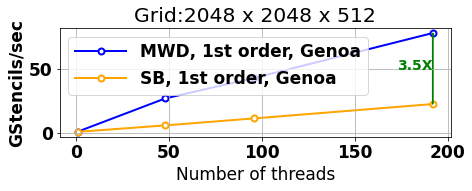

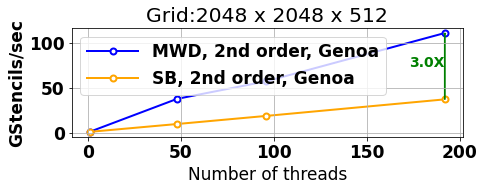

In [10]:
# ################
scalability_list=[]
print(data_summary['cores'].unique())
# thread_list=sorted(list(data_grid['cores'].unique()))
thread_list=[1,48,96,192]
# thread_list=[48,96,192]
# thread_list=[96,192]
for grid_ in grids_:
    data_grid_original=data_summary[data_summary['grids']==grid_]
    # for thread in sorted(list(data_grid['cores'].unique())):
    for thread in thread_list:
        # choose thread
        data_grid=data_grid_original[data_grid_original['cores']==thread]
        # choose method
        data_grid_sb=data_grid[data_grid['method']=='sb']
        data_grid_sb_abc=data_grid[data_grid['method']=='sb_abc']
        data_grid_tb=data_grid[data_grid['method']=='tb']
        data_grid_tb_abc=data_grid[data_grid['method']=='tb_abc']
        data_grid_sb_order2=data_grid[data_grid['method']=='sb_order2']
        data_grid_sb_order2_abc=data_grid[data_grid['method']=='sb_order2_abc']
        data_grid_tb_order2=data_grid[data_grid['method']=='tb_order2']
        data_grid_tb_order2_abc=data_grid[data_grid['method']=='tb_order2_abc']

        data_grid_sb=data_grid_sb.sort_values(by=['giga_point_s'],ascending=False)
        data_grid_sb_abc=data_grid_sb_abc.sort_values(by=['giga_point_s'],ascending=False)
        data_grid_tb=data_grid_tb.sort_values(by=['giga_point_s'],ascending=False)
        data_grid_tb_abc=data_grid_tb_abc.sort_values(by=['giga_point_s'],ascending=False)
        data_grid_sb_order2=data_grid_sb_order2.sort_values(by=['giga_point_s'],ascending=False)
        data_grid_sb_order2_abc=data_grid_sb_order2_abc.sort_values(by=['giga_point_s'],ascending=False)
        data_grid_tb_order2=data_grid_tb_order2.sort_values(by=['giga_point_s'],ascending=False)
        data_grid_tb_order2_abc=data_grid_tb_order2_abc.sort_values(by=['giga_point_s'],ascending=False)

        #######
        if len(data_grid_sb[metric].values)!=0:
            sb_val=data_grid_sb[metric].values[0]
        else:
            sb_val=math.nan

        if len(data_grid_sb_abc[metric].values)!=0:
            sb_abc_val=data_grid_sb_abc[metric].values[0]
        else:
            sb_abc_val=math.nan

        if len(data_grid_tb[metric].values)!=0:
            tb_val=data_grid_tb[metric].values[0]
        else:
            tb_val=math.nan

        if len(data_grid_tb_abc[metric].values)!=0:
            tb_abc_val=data_grid_tb_abc[metric].values[0]
        else:
            tb_abc_val=math.nan
        #######
        if len(data_grid_sb_order2[metric].values)!=0:
            sb_val2=data_grid_sb_order2[metric].values[0]
        else:
            sb_val2=math.nan

        if len(data_grid_sb_order2_abc[metric].values)!=0:
            sb_abc_val2=data_grid_sb_order2_abc[metric].values[0]
        else:
            sb_abc_val2=math.nan

        if len(data_grid_tb_order2[metric].values)!=0:
            tb_val2=data_grid_tb_order2[metric].values[0]
        else:
            tb_val2=math.nan

        if len(data_grid_tb_order2_abc[metric].values)!=0:
            tb_abc_val2=data_grid_tb_order2_abc[metric].values[0]
        else:
            tb_abc_val2=math.nan
        #######
        scalability_list.append([grid_,thread,sb_val,tb_val,sb_abc_val,tb_abc_val,sb_val2,tb_val2,sb_abc_val2,tb_abc_val2])
        print([grid_,thread,sb_val,tb_val,sb_abc_val,tb_abc_val,sb_val2,tb_val2,sb_abc_val2,tb_abc_val2])
        dd=1
        #######
df_scalability = pd.DataFrame(scalability_list)
writer = pd.ExcelWriter('scalability.xlsx')
df_scalability.columns =['grids','num_th','SB','TB','SB_abc','TB_abc','SB_order2','TB_order2','SB_order2_abc','TB_order2_abc']
df_scalability.to_excel(writer, sheet_name='welcome', index=False)
writer.save()
################
figures_root='../scaling'
# grid_name='2048 x 2048 x 512'
grid_name='2048 x 2048 x 512'
df_scalability_plot=df_scalability[df_scalability['grids']==grid_name]
df_scalability_plot=df_scalability_plot.sort_values(by=['SB_abc'],ascending=False)
sys='Genoa'
code_type_='1st'    #1st-abc
sb_source='SB'  #_abc
tb_source='TB'
labels={
        'Genoa-SB':'SB, 1st order, Genoa',
        'Genoa-TB':'MWD, 1st order, Genoa',
        }
colors=['blue','orange']
fig=plt.figure(figsize=(7,2.0))
for icolor,code in enumerate(['TB', 'SB']):
    if code=='SB':   
        yval=df_scalability_plot['SB_abc'];sb=yval.array[0];
    if code=='TB':   
        yval=df_scalability_plot['TB_abc'];tb=yval.array[0];
    plt.plot(df_scalability_plot['num_th'],yval,
            label=labels[sys+'-'+code],marker='o', linestyle='-',
            markersize=6,mfc='white', mew=2, lw=2,
            zorder=-1, clip_on=False,color=colors[icolor])
ax=plt.gca()

plt.axis('tight')
ax.grid(True)
ax.set_xlabel('Number of threads')
ax.set_ylabel('GStencils/sec',fontweight='bold')
ax.set_title('Grid:'+grid_name)
plt.legend(handlelength=3,loc='upper left')
# algo speedup
line1=ax.arrow(df_scalability_plot['num_th'].array[0],sb,0,(tb-sb), color='g', width=0.40, length_includes_head=True, head_length=1)
ax.annotate(str(np.round(tb/sb,1))+"X", xy=(df_scalability_plot['num_th'].array[0], (sb+tb)/2), xytext=(df_scalability_plot['num_th'].array[0]-df_scalability_plot['num_th'].array[0]/10,(sb+tb)/2-0.9), color='g', fontsize=14)
plt.show()

fig.savefig(os.path.join(figures_root,sys+'_'+code_type_+grid_name+'.png'), transparent=False, bbox_inches="tight",dpi=350)
fig.savefig(os.path.join(figures_root,sys+'_'+code_type_+grid_name+'.pdf'), transparent=False, bbox_inches="tight")
plt.close()
######
code_type_='2nd'
sb_source='SB_order2'
tb_source='TB_order2'
labels={
        'Genoa-SB':'SB, 2nd order, Genoa', 
        'Genoa-TB':'MWD, 2nd order, Genoa',
        }
colors=['blue','orange']
fig=plt.figure(figsize=(7,2.0))
for icolor,code in enumerate(['TB', 'SB']):
    if code=='SB':   
        yval=df_scalability_plot[sb_source];sb=yval.array[0];
    if code=='TB':   
        yval=df_scalability_plot[tb_source];tb=yval.array[0];
    plt.plot(df_scalability_plot['num_th'],yval,
            label=labels[sys+'-'+code],marker='o', linestyle='-',
            markersize=6,mfc='white', mew=2, lw=2,
            zorder=-1, clip_on=False,color=colors[icolor])
ax=plt.gca()

plt.axis('tight')
ax.grid(True);
ax.set_xlabel('Number of threads')
ax.set_ylabel('GStencils/sec',fontweight='bold')
ax.set_title('Grid:'+grid_name)
plt.legend(handlelength=3,loc='upper left')
# algo speedup
line1=ax.arrow(df_scalability_plot['num_th'].array[0],sb,0,(tb-sb), color='g', width=0.40, length_includes_head=True, head_length=1)
ax.annotate(str(np.round(tb/sb,1))+"X", xy=(df_scalability_plot['num_th'].array[0], (sb+tb)/2), xytext=(df_scalability_plot['num_th'].array[0]-df_scalability_plot['num_th'].array[0]/10,(sb+tb)/2-0.9), color='g', fontsize=14)
plt.show()

fig.savefig(os.path.join(figures_root,sys+'_'+code_type_+grid_name+'.png'), transparent=False, bbox_inches="tight",dpi=350)
fig.savefig(os.path.join(figures_root,sys+'_'+code_type_+grid_name+'.pdf'), transparent=False, bbox_inches="tight")
plt.close()